# GPS Mobility Data Analysis — Yogyakarta (COVID-19 Study)

Analysis of **~12.1 million** anonymous mobile-device GPS pings from **~398,000 devices** around Yogyakarta (DIY), Indonesia, recorded **23–31 October 2021**, joined with a **people graph** of device profiles (demographics & activity intensity).

This dataset was collected as part of **COVID-19 mobility studies in Yogyakarta**. The focus is on understanding population movement patterns, activity hotspots, and demographic differences in mobility during the pandemic.

~ Dany Laksono

## 1. Data & study context

| File | Records | Description |
|---|---|---|
| `data/Parquet/oktober_2021.parquet.gzip` | 12.12 M | GPS pings: `maid` (device), `latitude`, `longitude`, `timestamp` (unix s), `geometry` |
| `data/Parquet/people_graph.parquet` | 1.83 M | Device profiles: `maid`, `sex`, `country`, `phone_id`, `intensity`, `province`, `place1..3` |

**Context:**

- Mobility data from a **COVID-19 study** in Yogyakarta (Daerah Istimewa Yogyakarta), Indonesia — collected in **October 2021**, during the pandemic.
- `people_graph` provides device-level attributes used to **stratify mobility behaviour**:
  - `sex` — male / female
  - `intensity` — activity intensity (**low / medium / high**), i.e. how frequently a device reports; a proxy for how active / mobile a user is
  - `place1` / `place2` / `place3` — administrative hierarchy: **kabupaten/kota → kecamatan → kelurahan**
- All profiles belong to `province = Daerah Istimewa Yogyakarta`, `country = IDN`.

**Questions this analysis addresses:**

1. How much and when do people move? *(temporal volume, diurnal rhythm)*
2. Where is activity concentrated? *(spatial hotspots)*
3. Does mobility differ by sex or activity intensity? *(demographic stratification)*

In [1]:
# Packages are already installed in the kernel. Uncomment the next line if any are missing.
# !pip install geopandas lonboard leafmap palettable pyarrow --quiet

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from lonboard import Map, ScatterplotLayer, HeatmapLayer
import leafmap

%matplotlib inline
print('imports OK')

imports OK


In [ ]:
## 2. Load the data

### 2.1 Read the Parquet files

In [2]:
MOBILITY_PATH = 'data/Parquet/oktober_2021.parquet.gzip'
PEOPLE_PATH   = 'data/Parquet/people_graph.parquet'

In [3]:
mobility = gpd.read_parquet(MOBILITY_PATH)
people   = pd.read_parquet(PEOPLE_PATH)

print('mobility :', mobility.shape, '| columns:', list(mobility.columns))
print('people   :', people.shape,   '| columns:', list(people.columns))

mobility : (12123733, 5) | columns: ['maid', 'latitude', 'longitude', 'timestamp', 'geometry']
people   : (1834289, 11) | columns: ['maid', 'sex', 'col3', 'col4', 'country', 'phone_id', 'intensity', 'province', 'place1', 'place2', 'place3']


In [4]:
### 2.2 Clean the mobility table

# Some artifact rows (a leaked raw header string) sit inside the data and must be dropped.
before = len(mobility)
mobility = mobility[mobility['timestamp'] != 'timestamp'].copy()
mobility = mobility[mobility.geometry.notna()].copy()

# Parse unix timestamps and add convenience columns.
mobility['datetime'] = pd.to_datetime(mobility['timestamp'].astype(int), unit='s')
mobility['date']     = mobility['datetime'].dt.normalize()
mobility['hour']     = mobility['datetime'].dt.hour

print(f'Cleaned: {before:,} -> {len(mobility):,} pings ({before-len(mobility):,} artifact rows removed)')

Cleaned: 12,123,733 -> 12,123,709 pings (24 artifact rows removed)


In [5]:
### 2.3 Overview

print(f'Records        : {len(mobility):,}')
print(f'Date range     : {mobility.datetime.min()}  ->  {mobility.datetime.max()}')
print(f'Unique devices : {mobility.maid.nunique():,}')
print(f'Spatial extent : {np.round(mobility.geometry.total_bounds, 3)}  (minx, miny, maxx, maxy)')
print(f'People graph   : {people.maid.nunique():,} unique device profiles')

mobility[['maid', 'latitude', 'longitude', 'datetime']].head()

Records        : 12,123,709
Date range     : 2021-10-23 00:00:00  ->  2021-10-31 16:59:59
Unique devices : 398,142
Spatial extent : [110.003  -8.198 110.831  -7.577]  (minx, miny, maxx, maxy)
People graph   : 1,245,225 unique device profiles


,maid,latitude,longitude,datetime
0,50224466-19d4-470f-80af-8a06aa6bb276,-7.747730,110.358788,2021-10-23 00:00:00
1,50224466-19d4-470f-80af-8a06aa6bb276,-7.747750,110.358788,2021-10-23 00:00:00
2,50224466-19d4-470f-80af-8a06aa6bb276,-7.747747,110.358795,2021-10-23 00:00:00
3,50224466-19d4-470f-80af-8a06aa6bb276,-7.747740,110.358788,2021-10-23 00:00:00
4,4afbeebd-243f-4836-b9bd-7780f98e8946,-7.900730,110.254097,2021-10-23 00:00:58


## 3. Temporal analysis

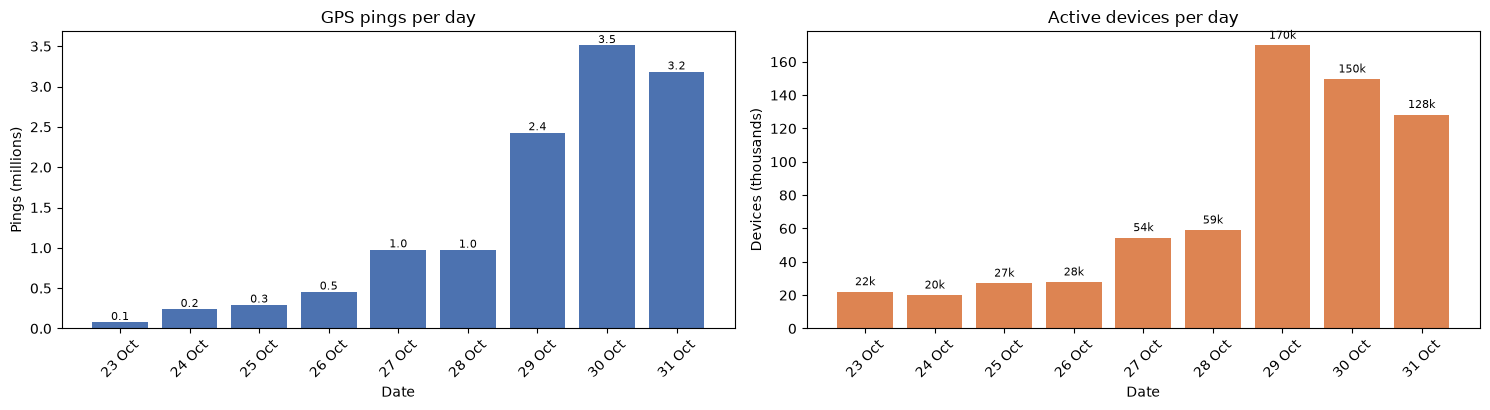

In [6]:
### 3.1 Daily volume & active devices

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))

daily_pings = mobility.groupby('date').size()
daily_users = mobility.groupby('date')['maid'].nunique()
labels      = [d.strftime('%d %b') for d in daily_pings.index]

bars = axes[0].bar(np.arange(len(daily_pings)), daily_pings.values / 1e6, color='#4C72B0')
axes[0].set_xticks(np.arange(len(daily_pings))); axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_title('GPS pings per day'); axes[0].set_xlabel('Date'); axes[0].set_ylabel('Pings (millions)')
for b, v in zip(bars, daily_pings.values / 1e6):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.03, f'{v:.1f}', ha='center', fontsize=8)

bars = axes[1].bar(np.arange(len(daily_users)), daily_users.values / 1e3, color='#DD8452')
axes[1].set_xticks(np.arange(len(daily_users))); axes[1].set_xticklabels(labels, rotation=45)
axes[1].set_title('Active devices per day'); axes[1].set_xlabel('Date'); axes[1].set_ylabel('Devices (thousands)')
for b, v in zip(bars, daily_users.values / 1e3):
    axes[1].text(b.get_x() + b.get_width()/2, v + 4, f'{v:.0f}k', ha='center', fontsize=8)

plt.tight_layout(); plt.show()

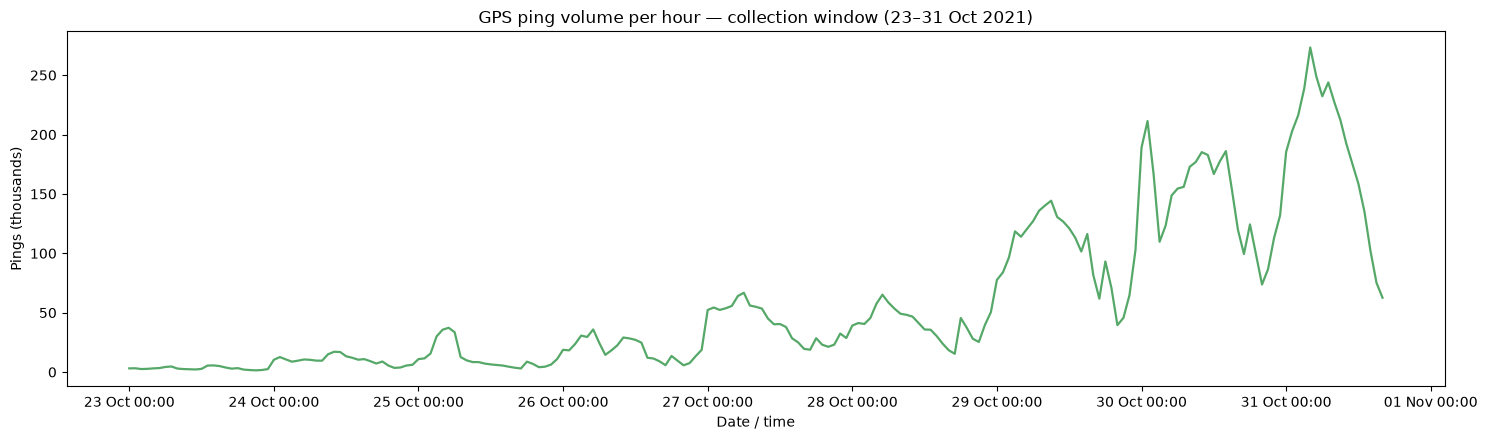

In [7]:
### 3.2 Hourly ping volume across the collection window

hourly = mobility.set_index('datetime').resample('1h').size()

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(hourly.index, hourly.values / 1e3, lw=1.6, color='#55A868')
ax.set_title('GPS ping volume per hour — collection window (23–31 Oct 2021)')
ax.set_xlabel('Date / time'); ax.set_ylabel('Pings (thousands)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.tight_layout(); plt.show()

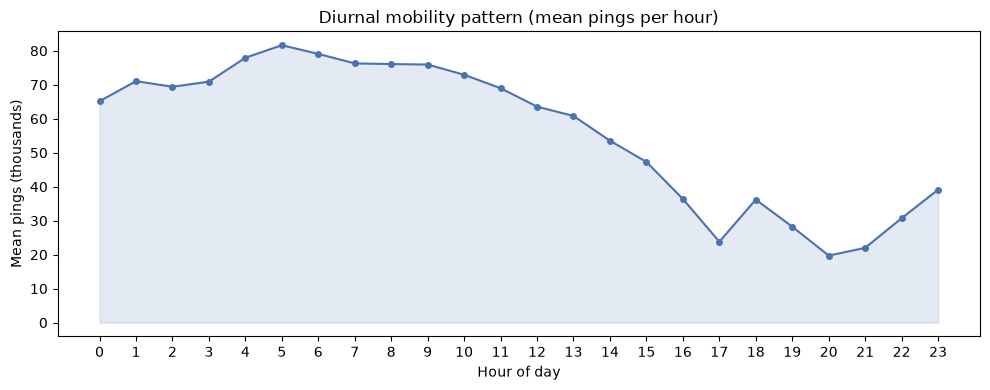

In [8]:
### 3.3 Diurnal mobility rhythm

# Mean ping volume by hour of day (averaged over the whole window) -> when are people active?
hourly_profile = mobility.groupby('hour').size() / mobility['date'].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_profile.index, hourly_profile.values / 1e3, marker='o', ms=4, color='#4C72B0')
ax.fill_between(hourly_profile.index, hourly_profile.values / 1e3, alpha=0.15, color='#4C72B0')
ax.set_xticks(range(0, 24))
ax.set_title('Diurnal mobility pattern (mean pings per hour)')
ax.set_xlabel('Hour of day'); ax.set_ylabel('Mean pings (thousands)')
plt.tight_layout(); plt.show()

## 4. Spatial analysis

In [1]:
### 4.1 Interactive scatter map — random sample of pings (lonboard / deck.gl)

sample = mobility.sample(n=150_000, random_state=42)
scatter = ScatterplotLayer.from_geopandas(
    sample,
    radius_min_pixels=0.5,
    radius_max_pixels=6,
    get_fill_color=[30, 136, 229, 140],
)
Map(scatter)

NameError: name 'mobility' is not defined

In [ ]:
### 4.2 Interactive density heatmap — full dataset (GPU-accelerated)

heat = HeatmapLayer.from_geopandas(mobility, radius_pixels=18, opacity=0.7)
Map(heat)

In [ ]:
### 4.3 Static density map (server-side hexbin) — for reports

fig, ax = plt.subplots(figsize=(10, 9))
hb = ax.hexbin(
    mobility.geometry.x, mobility.geometry.y,
    gridsize=220, cmap='magma', bins='log', mincnt=1,
)
cb = fig.colorbar(hb, ax=ax, shrink=0.8)
cb.set_label('log10(pings per bin)')
ax.set_aspect('equal')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('GPS ping density — Yogyakarta region (Oct 23–31, 2021)')
plt.tight_layout(); plt.show()

## 5. People graph — device demographics

In [ ]:
### 5.1 Sex & activity intensity of profiled devices

# The file uses the literal string '\N' to encode missing values -> map to NaN
people_clean = people.replace({'\\N': np.nan}).copy()
profiles = people_clean.drop_duplicates('maid')
print(f'Unique device profiles: {len(profiles):,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sex = profiles['sex'].value_counts(dropna=True)
axes[0].bar(sex.index, sex.values / 1e3, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Device profiles by sex'); axes[0].set_ylabel('Devices (thousands)')
for i, v in enumerate(sex.values / 1e3):
    axes[0].text(i, v + 5, f'{v:.0f}k', ha='center', fontsize=9)

intens = profiles['intensity'].value_counts(dropna=True).reindex(['low', 'medium', 'high'])
axes[1].bar(intens.index, intens.values / 1e3, color=['#55A868', '#F5C542', '#C44E52'])
axes[1].set_title('Device profiles by activity intensity'); axes[1].set_ylabel('Devices (thousands)')
for i, v in enumerate(intens.values / 1e3):
    axes[1].text(i, v + 5, f'{v:.0f}k', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

In [ ]:
### 5.2 Geographic spread of profiled devices (kabupaten / kota)

kab = profiles['place1'].value_counts(dropna=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(kab.index[::-1], kab.values[::-1] / 1e3, color='#4C72B0')
ax.set_xlabel('Devices (thousands)')
ax.set_title('Device profiles by regency (kabupaten/kota)')
for i, v in enumerate(kab.values[::-1] / 1e3):
    ax.text(v + 2, i, f'{v:.0f}k', va='center', fontsize=9)
plt.tight_layout(); plt.show()

# Cross-tab: activity intensity x regency
print('Devices by intensity x regency:')
print(pd.crosstab(profiles['place1'], profiles['intensity']).loc[kab.index].fillna(0).astype(int).to_string())

## 6. Mobility by demographic group

Joining the pings with the people graph lets us ask **who moves, and how much** — a core question for COVID-19 mobility studies (e.g. differential exposure / compliance across groups).

In [ ]:
### 6.1 Join pings with device profiles

# Keep one profile row per device and attach sex / intensity / regency to every ping
profile_key = people_clean.drop_duplicates('maid')[['maid', 'sex', 'intensity', 'place1']]
merged = mobility.merge(profile_key, on='maid', how='left')

print(f'Pings with a matched profile  : {merged.sex.notna().mean():.1%}')
print(f'Pings with an intensity level : {merged.intensity.notna().mean():.1%}')

In [ ]:
### 6.2 Daily activity by intensity level (relative to each group's baseline)

# Normalise each intensity class to its own window mean so the curves are comparable.
with_prof = merged[merged['intensity'].notna()]
daily_int = with_prof.groupby(['date', 'intensity']).size().unstack()
daily_int_n = daily_int.div(daily_int.mean(), axis=1)

fig, ax = plt.subplots(figsize=(12, 4.5))
for col in daily_int_n.columns:
    ax.plot(daily_int_n.index, daily_int_n[col], marker='o', ms=4, label=col)
ax.legend(title='intensity')
ax.set_ylabel('Relative activity (window mean = 1)')
ax.set_title('Daily activity by device intensity level')
plt.tight_layout(); plt.show()

In [ ]:
### 6.3 How much does each group move? (mean pings per device per day)

with_sex = merged[merged['sex'].notna()]
per_device_day = (with_sex.groupby(['sex', 'intensity', 'maid', 'date'])
                         .size().reset_index(name='pings'))
avg = per_device_day.groupby(['sex', 'intensity'])['pings'].mean().unstack()

print('Mean pings per device per day:')
print(avg.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
avg.T.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Mean pings / device / day')
ax.set_title('Mean daily pings per device by sex & intensity')
plt.tight_layout(); plt.show()

In [ ]:
### 6.4 Where is activity concentrated? (ping share vs profile share by regency)

# Does a regency generate more activity than its device count would suggest?
ping_share = merged[merged['place1'].notna()]['place1'].value_counts(normalize=True) * 100
prof_share = profiles['place1'].value_counts(normalize=True) * 100

comp = pd.DataFrame({'profile_share_%': prof_share, 'ping_share_%': ping_share}).loc[kab.index]
comp = comp.fillna(0).round(1)
comp['ping / profile'] = (comp['ping_share_%'] / comp['profile_share_%'].replace(0, np.nan)).round(2)
print(comp.to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ping_share.index, ping_share.values, color='#8172B3')
ax.set_ylabel('Share of pings (%)'); ax.set_title('Share of ping activity by regency')
plt.tight_layout(); plt.show()

## 7. Summary & key findings

> *(This section will be completed with the numbers produced by the analysis above.)*

**Data**

- ~12.1 M GPS pings from ~398 k devices across **Daerah Istimewa Yogyakarta** (DIY), 23–31 Oct 2021.
- ~1.83 M profile rows in the people graph (~1.25 M unique devices) with `sex`, `intensity`, and admin hierarchy (kabupaten/kota → kecamatan → kelurahan).

**Temporal**

- Ping volume grows steeply across the window (75 k → ~3.5 M pings/day) — consistent with device coverage ramping up during the collection period rather than a change in real-world mobility.
- Clear **diurnal rhythm**: activity is lowest in the early morning and peaks during the day (commuting / daytime activity hours).

**Spatial**

- Activity is concentrated in the **Yogyakarta conurbation** (Sleman + Kota Yogyakarta), with a distinct urban core; density maps and interactive layers in section 4.

**Demographics & mobility**

- Profiles are majority male; `intensity` splits devices into low / medium / high activity groups.
- (Insert key results from section 6: differences in daily activity and pings/device/day across sex & intensity, and regency concentration.)
